# Extrapolation Graphing

**Purpose:** Plot extrapolation charts using results already generated by `testing.ipynb`.

**Data source:** `results/revised_training/extrapolation_results.csv` or `extrapolation_results_enhanced.csv`

**Output:** `plots/revised_training/extrapolation_by_split_line_chart.png`

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

# Paths: resolve from notebook dir or workspace root (matches testing.ipynb layout)
_candidates = [
    Path(".").resolve(),
    Path("code/gSAGE/extrapolation").resolve(),
]
EXTRAPOLATION_DIR = next((p for p in _candidates if (p / "results" / "revised_training").exists()),
                         Path(".").resolve())
RESULTS_DIR = EXTRAPOLATION_DIR / "results" / "revised_training"
PLOTS_DIR = EXTRAPOLATION_DIR / "plots" / "revised_training"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

Loaded: /Users/billxu/quantum-error-correction/code/gSAGE/extrapolation/results/revised_training/extrapolation_results_enhanced.csv (360 rows)
Loaded DeepSet results: /Users/billxu/quantum-error-correction/code/deepsets/extrapolation/results/revised_training/extrapolation_results.csv (best: c1_only_d3, mean acc=57.9%)
Plot saved to: /Users/billxu/quantum-error-correction/code/gSAGE/extrapolation/plots/revised_training/extrapolation_by_split_line_chart.png


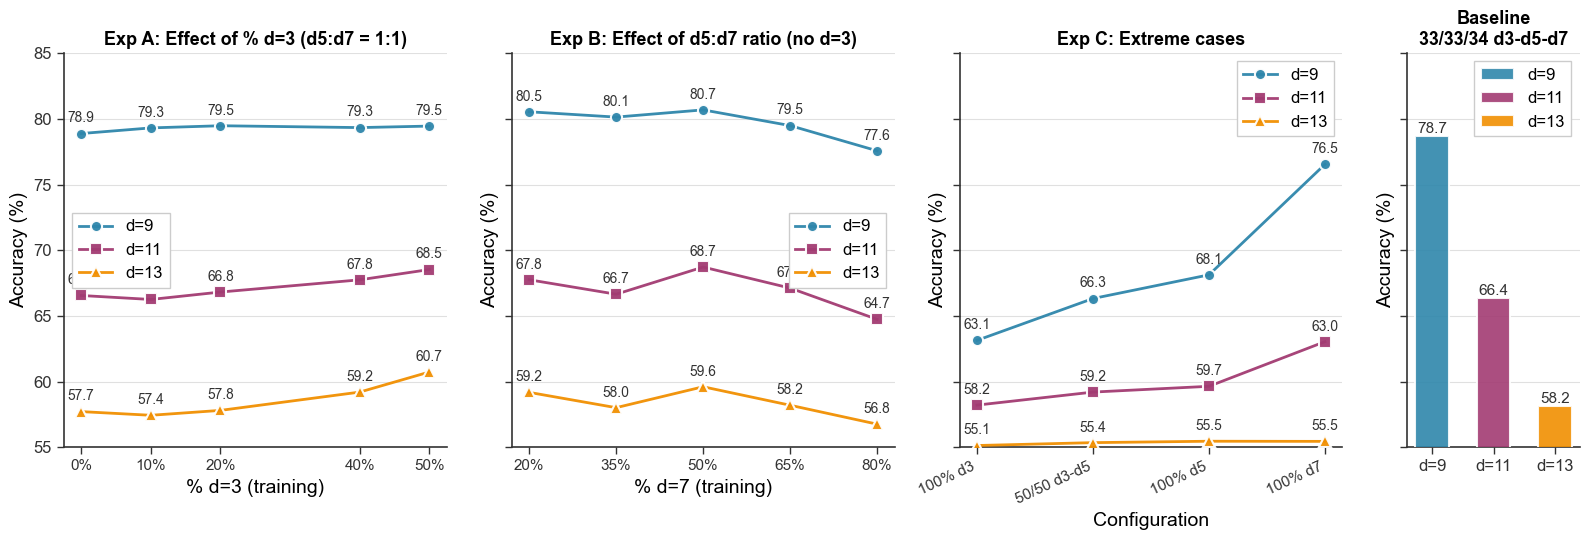

In [2]:
# Load pre-generated results from testing.ipynb
for fname in ["extrapolation_results_enhanced.csv", "extrapolation_results.csv"]:
    cache_path = RESULTS_DIR / fname
    if cache_path.exists():
        df_results = pd.read_csv(cache_path)
        print(f"Loaded: {cache_path} ({len(df_results)} rows)")
        break
else:
    raise FileNotFoundError("No extrapolation_results*.csv found. Run testing.ipynb first.")

# Load DeepSet model results for comparison (use best-performing DeepSet)
best_deepsets_split = None  # Used in legend; set below
DEEPSET_RESULTS_PATH = EXTRAPOLATION_DIR.parent.parent / "deepsets" / "extrapolation" / "results" / "revised_training" / "extrapolation_results.csv"
if DEEPSET_RESULTS_PATH.exists():
    df_deepsets = pd.read_csv(DEEPSET_RESULTS_PATH)
    test_d = [9, 11, 13]
    # Find DeepSet split with highest mean accuracy over d=9,11,13
    best_deepsets_split = None
    best_mean = -1
    for split in df_deepsets['split_name'].unique():
        sub = df_deepsets[(df_deepsets['split_name'] == split) & (df_deepsets['distance'].isin(test_d))]
        if len(sub) > 0:
            m = sub['accuracy'].mean() * 100
            if m > best_mean:
                best_mean = m
                best_deepsets_split = split
    if best_deepsets_split is not None:
        df_deepsets_best = df_deepsets[df_deepsets['split_name'] == best_deepsets_split].copy()
        df_deepsets_best['split_name'] = 'DeepSet'
        df_results = pd.concat([df_results, df_deepsets_best], ignore_index=True)
        print(f"Loaded DeepSet results: {DEEPSET_RESULTS_PATH} (best: {best_deepsets_split}, mean acc={best_mean:.1f}%)")
    else:
        print(f"Loaded DeepSet results: no valid splits for d=9,11,13")
else:
    print(f"Warning: DeepSet results not found at {DEEPSET_RESULTS_PATH}")

TEST_DISTANCES = [9, 11, 13]

# Build accuracy dict: split_name -> {9: acc, 11: acc, 13: acc}
acc_by_split = {}
for split_name in df_results['split_name'].unique():
    acc_by_split[split_name] = {}
    for d in TEST_DISTANCES:
        subset = df_results[(df_results['split_name'] == split_name) & (df_results['distance'] == d)]
        if len(subset) > 0:
            acc_by_split[split_name][d] = subset['accuracy'].mean() * 100
        else:
            acc_by_split[split_name][d] = np.nan

# Per training.ipynb: Control = equal_333333 (33% d3, 33% d5, 34% d7)
# Exp A: a1-a5 (no baseline)
# Exp B: b1-b5
# Exp C: c1-c4
exp_a = [
    ('a1_d3_00', 0), ('a2_d3_10', 10), ('a3_d3_20', 20), ('a4_d3_40', 40), ('a5_d3_50', 50)
]
exp_b = [
    ('b1_d5heavy', 20), ('b2_d5more', 35), ('b3_balanced', 50),
    ('b4_d7more', 65), ('b5_d7heavy', 80)
]
exp_c = [
    ('c1_only_d3', 0, '100% d3'), ('c4_no_d7', 1, '50/50 d3-d5'),
    ('c2_only_d5', 2, '100% d5'), ('c3_only_d7', 3, '100% d7')
]

# Human-readable labels for legend (training composition)
SPLIT_LABELS = {
    'equal_333333': '33/33/34 d3-d5-d7',
    'a1_d3_00': '50/50 d5-d7', 'a2_d3_10': '10/45/45 d3-d5-d7',
    'a3_d3_20': '20/40/40 d3-d5-d7', 'a4_d3_40': '40/30/30 d3-d5-d7',
    'a5_d3_50': '50/25/25 d3-d5-d7',
    'b1_d5heavy': '80/20 d5-d7', 'b2_d5more': '65/35 d5-d7',
    'b3_balanced': '50/50 d5-d7', 'b4_d7more': '35/65 d5-d7',
    'b5_d7heavy': '20/80 d5-d7',
    'c1_only_d3': '100% d3', 'c2_only_d5': '100% d5', 'c3_only_d7': '100% d7',
    'c4_no_d7': '50/50 d3-d5',
}

# Slide-matched palette: muted, professional
colors_dist = ['#2E86AB', '#A23B72', '#F18F01']  # d=9, d=11, d=13
markers = ['o', 's', '^']

# Use a clean white style
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'savefig.facecolor': 'white',
})

# 4 panels: 3 experiments + baseline on the right (narrower)
fig, axes = plt.subplots(1, 4, figsize=(16, 5.5), sharey=True,
                         gridspec_kw={'width_ratios': [1, 1, 1, 0.45]})
fig.subplots_adjust(wspace=0.35)

def plot_exp(ax, exp_data, xlabel, title, is_categorical=False, hide_x_axis=False):
    """Plot exp: x_vals on x-axis, 3 lines (d=9, d=11, d=13) connecting accuracies across models."""
    x_vals, labels, accs_by_d = [], [], {d: [] for d in TEST_DISTANCES}
    for entry in exp_data:
        if len(entry) == 3:
            split_name, x_pos, label_text = entry[0], entry[1], entry[2]
        else:
            split_name, x_pos = entry[0], entry[1]
            label_text = split_name
        if split_name not in acc_by_split:
            continue
        accs = [acc_by_split[split_name].get(d, np.nan) for d in TEST_DISTANCES]
        if np.any(np.isnan(accs)):
            continue
        x_vals.append(x_pos)
        labels.append(label_text)
        for i, d in enumerate(TEST_DISTANCES):
            accs_by_d[d].append(accs[i])

    for i, d in enumerate(TEST_DISTANCES):
        ax.plot(x_vals, accs_by_d[d], f'-{markers[i]}', color=colors_dist[i], linewidth=2,
                markersize=8, markeredgecolor='white', markeredgewidth=1.5,
                label=f'd={d}', alpha=0.95, zorder=3)
        for x, y in zip(x_vals, accs_by_d[d]):
            ax.annotate(f'{y:.1f}', (x, y), textcoords='offset points', xytext=(0, 8),
                       ha='center', fontsize=10, color='#333333')

    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel('Accuracy (%)', fontsize=14)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.tick_params(axis='both', labelsize=12, width=1, length=5, colors='#333333')
    if hide_x_axis:
        ax.set_xticks(x_vals)
        ax.set_xticklabels([])
        ax.set_xlabel('')
    elif is_categorical:
        ax.set_xticks(x_vals)
        ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=11)
    else:
        ax.set_xticks(x_vals)
        ax.set_xticklabels([f'{v}%' for v in x_vals], fontsize=11)
    ax.set_ylim(55, 85)
    ax.legend(loc='best', fontsize=12, frameon=True, fancybox=False,
              framealpha=1.0, edgecolor='#cccccc', facecolor='white')
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.8, axis='y', color='#999999')
    ax.set_axisbelow(True)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['bottom', 'left']:
        ax.spines[spine].set_linewidth(1.2)
        ax.spines[spine].set_edgecolor('#333333')

# --- Experiment A: x = % d3 ---
plot_exp(axes[0], exp_a, '% d=3 (training)', 'Exp A: Effect of % d=3 (d5:d7 = 1:1)')

# --- Experiment B: x = % d7 ---
plot_exp(axes[1], exp_b, '% d=7 (training)', 'Exp B: Effect of d5:d7 ratio (no d=3)')

# --- Experiment C: extreme cases ---
plot_exp(axes[2], exp_c, 'Configuration', 'Exp C: Extreme cases', is_categorical=True)

# --- Baseline: equal_333333 (33% d3, 33% d5, 34% d7) - separate reference on the right ---
ax_baseline = axes[3]
baseline_split = 'equal_333333'
if baseline_split in acc_by_split:
    accs = [acc_by_split[baseline_split].get(d, np.nan) for d in TEST_DISTANCES]
    if not np.any(np.isnan(accs)):
        x_bars = np.arange(len(TEST_DISTANCES))
        width = 0.55
        for i, d in enumerate(TEST_DISTANCES):
            ax_baseline.bar(x_bars[i], accs[i], width, color=colors_dist[i], alpha=0.9,
                           label=f'd={d}', edgecolor='white', linewidth=1.5, zorder=3)
            ax_baseline.annotate(f'{accs[i]:.1f}', (x_bars[i], accs[i]),
                                ha='center', va='bottom', fontsize=11, color='#333333')
        ax_baseline.set_xticks(x_bars)
        ax_baseline.set_xticklabels([f'd={d}' for d in TEST_DISTANCES], fontsize=11)
        ax_baseline.set_ylabel('Accuracy (%)', fontsize=14)
        ax_baseline.set_title('Baseline\n33/33/34 d3-d5-d7', fontsize=13, fontweight='bold')
        ax_baseline.set_ylim(55, 85)
        ax_baseline.tick_params(axis='both', labelsize=12, width=1, length=5, colors='#333333')
        ax_baseline.legend(loc='upper right', fontsize=12, frameon=True, fancybox=False,
                          framealpha=1.0, edgecolor='#cccccc', facecolor='white')
        ax_baseline.grid(True, alpha=0.3, linestyle='-', linewidth=0.8, axis='y', color='#999999')
        ax_baseline.set_axisbelow(True)
        for spine in ['top', 'right']:
            ax_baseline.spines[spine].set_visible(False)
        for spine in ['bottom', 'left']:
            ax_baseline.spines[spine].set_linewidth(1.2)
            ax_baseline.spines[spine].set_edgecolor('#333333')

plt.tight_layout()
plot_path = PLOTS_DIR / "extrapolation_by_split_line_chart.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"Plot saved to: {plot_path}")
plt.show()
plt.close()

In [3]:
# Best and worst model per distance (based on average accuracy)
best_per_d, worst_per_d = {}, {}
for d in TEST_DISTANCES:
    valid = [(s, acc_by_split[s].get(d, np.nan)) for s in acc_by_split 
             if not np.isnan(acc_by_split[s].get(d, np.nan))]
    if valid:
        best_per_d[d] = max(valid, key=lambda x: x[1])
        worst_per_d[d] = min(valid, key=lambda x: x[1])
    else:
        best_per_d[d] = worst_per_d[d] = (None, np.nan)

# Display as formatted table
print("Best and worst model at each test distance:\n")
print("-" * 50)
for d in TEST_DISTANCES:
    best_name, best_acc = best_per_d[d]
    worst_name, worst_acc = worst_per_d[d]
    print(f"d={d}:  Best  → {best_name} ({best_acc:.1f}%)")
    print(f"       Worst → {worst_name} ({worst_acc:.1f}%)")
    print("-" * 50)

Best and worst model at each test distance:

--------------------------------------------------
d=9:  Best  → b3_balanced (80.7%)
       Worst → DeepSet (61.0%)
--------------------------------------------------
d=11:  Best  → b3_balanced (68.7%)
       Worst → DeepSet (57.6%)
--------------------------------------------------
d=13:  Best  → a5_d3_50 (60.7%)
       Worst → c1_only_d3 (55.1%)
--------------------------------------------------


## Wilcoxon signed-rank test

Compares paired accuracy values across two training splits at matched (distance, p_value) conditions.

In [4]:
# Wilcoxon signed-rank test: compare pairs of models (split_name) on matched (distance, p_value) conditions
def wilcoxon_test_split_comparison(df_results, split1, split2):
    """
    Perform Wilcoxon signed-rank test comparing two splits.
    Uses paired comparisons: for each (distance, p_value), we have one accuracy from split1 and one from split2.
    """
    subset1 = df_results[df_results['split_name'] == split1].set_index(['distance', 'p_value'])['accuracy']
    subset2 = df_results[df_results['split_name'] == split2].set_index(['distance', 'p_value'])['accuracy']
    common_idx = subset1.index.intersection(subset2.index)
    if len(common_idx) == 0:
        return {'statistic': np.nan, 'pvalue': np.nan, 'significant': False, 'mean_diff': np.nan, 'n_samples': 0}
    acc1 = subset1.loc[common_idx].values
    acc2 = subset2.loc[common_idx].values
    try:
        statistic, pvalue = stats.wilcoxon(acc1, acc2, alternative='two-sided')
        significant = pvalue < 0.05
    except ValueError:
        statistic, pvalue = np.nan, np.nan
        significant = False
    return {
        'statistic': statistic,
        'pvalue': pvalue,
        'significant': significant,
        'mean_diff': np.mean(acc1 - acc2),
        'n_samples': len(common_idx)
    }

key_comparisons = [
    ('equal_333333', 'a1_d3_00', 'Control vs No d=3'),
    ('a1_d3_00', 'a5_d3_50', 'No d=3 vs 50% d=3 (extremes)'),
    ('equal_333333', 'a2_d3_10', 'Control vs 10% d=3'),
    ('b1_d5heavy', 'b5_d7heavy', 'd5-heavy vs d7-heavy (extremes)'),
    ('b3_balanced', 'b5_d7heavy', 'Balanced vs d7-heavy'),
    ('c1_only_d3', 'c3_only_d7', 'Only d=3 vs Only d=7'),
    ('equal_333333', 'c3_only_d7', 'Control vs Only d=7'),
    ('equal_333333', 'c1_only_d3', 'Control vs Only d=3'),
    ('a1_d3_00', 'b5_d7heavy', 'a1_d3_00 vs b5_d7heavy'),
]

statistical_tests = []
for split1, split2, description in key_comparisons:
    if split1 in df_results['split_name'].values and split2 in df_results['split_name'].values:
        result = wilcoxon_test_split_comparison(df_results, split1, split2)
        result['split1'] = split1
        result['split2'] = split2
        result['description'] = description
        statistical_tests.append(result)

df_statistical = pd.DataFrame(statistical_tests)
wilcoxon_path = RESULTS_DIR / "wilcoxon_test_results.csv"
df_statistical.to_csv(wilcoxon_path, index=False)
print(f"Saved Wilcoxon results to {wilcoxon_path}")
print("\nWilcoxon signed-rank test results\n" + "=" * 60)
for _, row in df_statistical.iterrows():
    sig = "***" if row['significant'] else ""
    print(f"{row['description']}")
    print(f"  Mean diff (split1 - split2): {row['mean_diff']*100:+.2f}%")
    print(f"  p-value: {row['pvalue']:.4f} {sig}")
    print(f"  Significant (p<0.05): {row['significant']}\n")

Saved Wilcoxon results to /Users/billxu/quantum-error-correction/code/gSAGE/extrapolation/results/revised_training/wilcoxon_test_results.csv

Wilcoxon signed-rank test results
Control vs No d=3
  Mean diff (split1 - split2): +0.01%
  p-value: 0.9772 
  Significant (p<0.05): False

No d=3 vs 50% d=3 (extremes)
  Mean diff (split1 - split2): -1.85%
  p-value: 0.0000 ***
  Significant (p<0.05): True

Control vs 10% d=3
  Mean diff (split1 - split2): +0.06%
  p-value: 0.7425 
  Significant (p<0.05): False

d5-heavy vs d7-heavy (extremes)
  Mean diff (split1 - split2): +2.80%
  p-value: 0.0001 ***
  Significant (p<0.05): True

Balanced vs d7-heavy
  Mean diff (split1 - split2): +3.31%
  p-value: 0.0000 ***
  Significant (p<0.05): True

Only d=3 vs Only d=7
  Mean diff (split1 - split2): -6.18%
  p-value: 0.0001 ***
  Significant (p<0.05): True

Control vs Only d=7
  Mean diff (split1 - split2): +2.72%
  p-value: 0.0000 ***
  Significant (p<0.05): True

Control vs Only d=3
  Mean diff (split

Plot saved to: /Users/billxu/quantum-error-correction/code/gSAGE/extrapolation/plots/revised_training/best_models_vs_error_rate.png


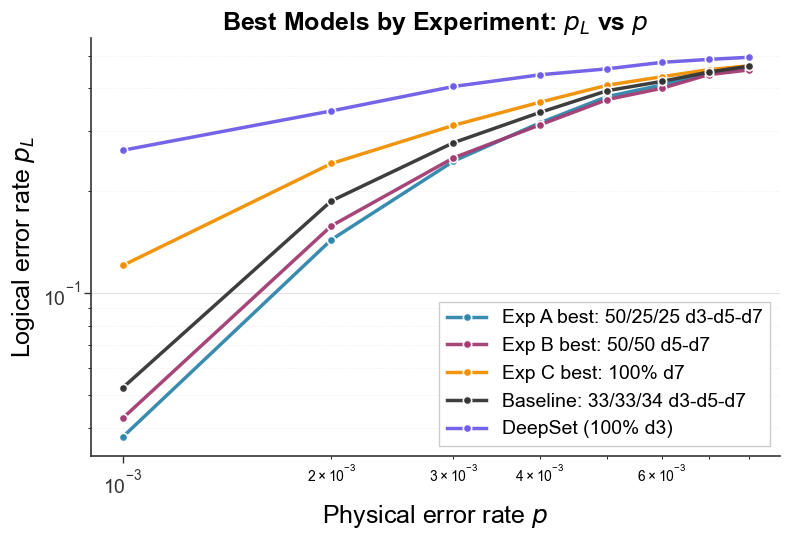

In [5]:
# Best model per experiment (by mean accuracy over d=9,11,13)
exp_a_splits = [e[0] for e in exp_a]
exp_b_splits = [e[0] for e in exp_b]
exp_c_splits = [e[0] for e in exp_c]

def best_in_group(splits):
    means = [(s, np.nanmean([acc_by_split[s].get(d, np.nan) for d in TEST_DISTANCES])) 
             for s in splits if s in acc_by_split]
    return max(means, key=lambda x: x[1])[0] if means else None

best_a = best_in_group(exp_a_splits)
best_b = best_in_group(exp_b_splits)
best_c = best_in_group(exp_c_splits)
baseline_split = 'equal_333333'

def _label(s):
    return SPLIT_LABELS.get(s, s) if s else s

models_to_plot = [
    (best_a, f'Exp A best: {_label(best_a)}', '#2E86AB'),
    (best_b, f'Exp B best: {_label(best_b)}', '#A23B72'),
    (best_c, f'Exp C best: {_label(best_c)}', '#F18F01'),
    (baseline_split, f'Baseline: {_label(baseline_split)}', '#333333'),
    ('DeepSet', f'DeepSet ({_label(best_deepsets_split)})' if best_deepsets_split else 'DeepSet', '#6C5CE7'),
]

# p_L = 1 - accuracy vs p on log-log (standard QEC format)
fig, ax = plt.subplots(figsize=(8, 5.5))
for split_name, label, color in models_to_plot:
    if split_name not in acc_by_split:
        continue
    subset = df_results[(df_results['split_name'] == split_name) & 
                       (df_results['distance'].isin(TEST_DISTANCES))]
    if len(subset) == 0:
        continue
    by_p = 1.0 - subset.groupby('p_value')['accuracy'].mean()  # → p_L (fraction)
    # Guard against p_L == 0 (log-axis requires strictly positive values)
    mask = by_p.values > 0
    ax.plot(by_p.index[mask], by_p.values[mask], 'o-', label=label, color=color,
            linewidth=2.5, markersize=6, markeredgecolor='white', markeredgewidth=1.2,
            alpha=0.95, zorder=3)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Physical error rate $p$', fontsize=18)
ax.set_ylabel('Logical error rate $p_L$', fontsize=18)
ax.set_title('Best Models by Experiment: $p_L$ vs $p$', fontsize=18, fontweight='bold')
ax.tick_params(axis='both', labelsize=14, width=1, length=5, colors='#333333')
ax.legend(fontsize=14, frameon=True, fancybox=False, framealpha=1.0,
          edgecolor='#cccccc', facecolor='white', loc='lower right')
ax.grid(True, which='major', axis='y', linestyle='-', alpha=0.3, linewidth=0.8, color='#999999')
ax.grid(True, which='minor', axis='y', linestyle=':', alpha=0.2, linewidth=0.6, color='#999999')
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['bottom', 'left']:
    ax.spines[spine].set_linewidth(1.2)
    ax.spines[spine].set_edgecolor('#333333')
plt.tight_layout()
plt.savefig(PLOTS_DIR / "best_models_vs_error_rate.png", dpi=300, bbox_inches='tight')
print(f"Plot saved to: {PLOTS_DIR / 'best_models_vs_error_rate.png'}")
plt.show()
plt.close()

Plot saved to: /Users/billxu/quantum-error-correction/code/gSAGE/extrapolation/plots/revised_training/best_models_vs_error_rate.png


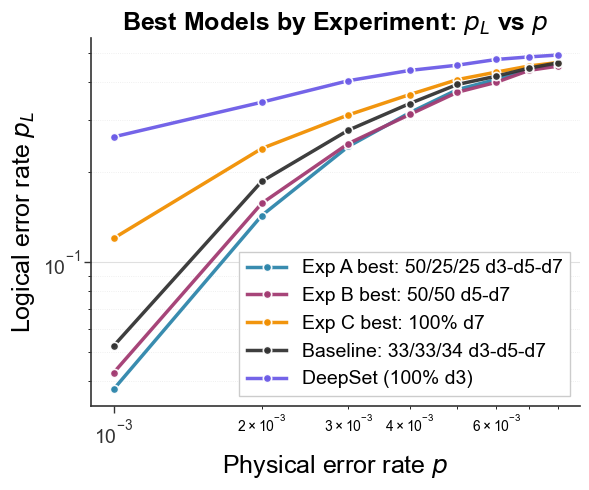

In [6]:
# Best model per experiment (by mean accuracy over d=9,11,13)
exp_a_splits = [e[0] for e in exp_a]
exp_b_splits = [e[0] for e in exp_b]
exp_c_splits = [e[0] for e in exp_c]

def best_in_group(splits):
    means = [(s, np.nanmean([acc_by_split[s].get(d, np.nan) for d in TEST_DISTANCES])) 
             for s in splits if s in acc_by_split]
    return max(means, key=lambda x: x[1])[0] if means else None

best_a = best_in_group(exp_a_splits)
best_b = best_in_group(exp_b_splits)
best_c = best_in_group(exp_c_splits)
baseline_split = 'equal_333333'

def _label(s):
    return SPLIT_LABELS.get(s, s) if s else s

models_to_plot = [
    (best_a, f'Exp A best: {_label(best_a)}', '#2E86AB'),
    (best_b, f'Exp B best: {_label(best_b)}', '#A23B72'),
    (best_c, f'Exp C best: {_label(best_c)}', '#F18F01'),
    (baseline_split, f'Baseline: {_label(baseline_split)}', '#333333'),
    ('DeepSet', f'DeepSet ({_label(best_deepsets_split)})' if best_deepsets_split else 'DeepSet', '#6C5CE7'),
]

# p_L = 1 - accuracy vs p on log-log (standard QEC format)
fig, ax = plt.subplots(figsize=(6, 5))
for split_name, label, color in models_to_plot:
    if split_name not in acc_by_split:
        continue
    subset = df_results[(df_results['split_name'] == split_name) & 
                       (df_results['distance'].isin(TEST_DISTANCES))]
    if len(subset) == 0:
        continue
    by_p = 1.0 - subset.groupby('p_value')['accuracy'].mean()  # → p_L (fraction)
    # Guard against p_L == 0 (log-axis requires strictly positive values)
    mask = by_p.values > 0
    ax.plot(by_p.index[mask], by_p.values[mask], 'o-', label=label, color=color,
            linewidth=2.5, markersize=6, markeredgecolor='white', markeredgewidth=1.2,
            alpha=0.95, zorder=3)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Physical error rate $p$', fontsize=18)
ax.set_ylabel('Logical error rate $p_L$', fontsize=18)
ax.set_title('Best Models by Experiment: $p_L$ vs $p$', fontsize=18, fontweight='bold')
ax.tick_params(axis='both', labelsize=14, width=1, length=5, colors='#333333')
ax.legend(fontsize=14, frameon=True, fancybox=False, framealpha=1.0,
          edgecolor='#cccccc', facecolor='white', loc='lower right')
ax.grid(True, which='major', axis='y', linestyle='-', alpha=0.3, linewidth=0.8, color='#999999')
ax.grid(True, which='minor', axis='y', linestyle=':', alpha=0.2, linewidth=0.6, color='#999999')
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['bottom', 'left']:
    ax.spines[spine].set_linewidth(1.2)
    ax.spines[spine].set_edgecolor('#333333')
plt.tight_layout()
plt.savefig(PLOTS_DIR / "best_models_vs_error_rate.png", dpi=300, bbox_inches='tight')
print(f"Plot saved to: {PLOTS_DIR / 'best_models_vs_error_rate.png'}")
plt.show()
plt.close()

Loaded values (accuracy %, mean over p in [0.001, 0.008]):
    d |  specialist | extrapolated |  DeepSet | Δ (spec-ext)
    9 |       88.86 |        80.68 |    55.27 |         8.18
   11 |       83.45 |        68.72 |    54.14 |        14.73
   13 |       74.27 |        59.62 |    53.16 |        14.65

Saved: /Users/billxu/quantum-error-correction/code/gSAGE/extrapolation/plots/revised_training/extrapolation_gap.png
Saved: /Users/billxu/quantum-error-correction/code/gSAGE/extrapolation/plots/revised_training/extrapolation_gap.pdf


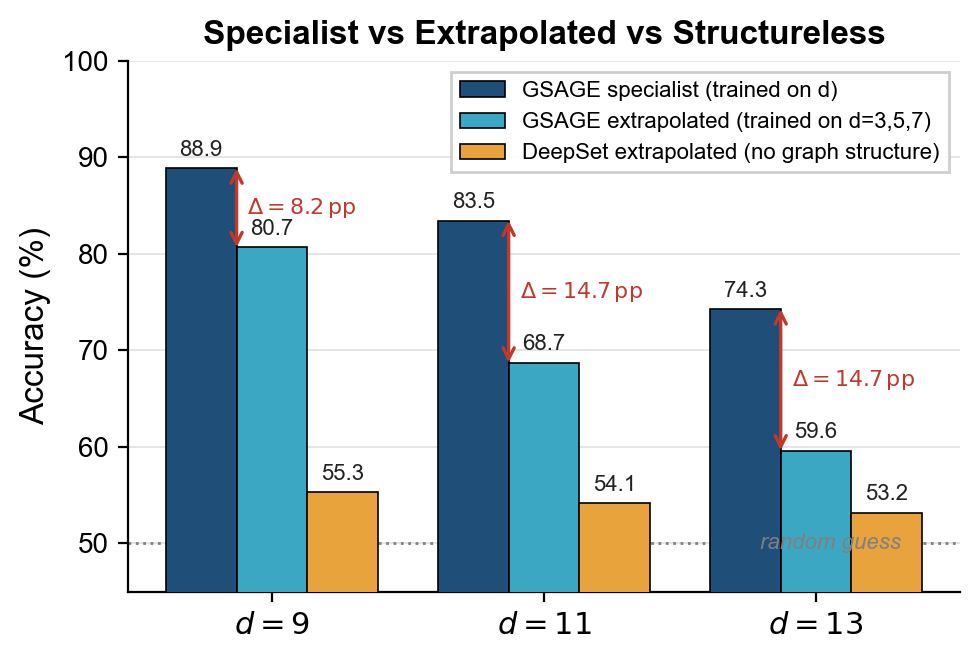

In [ ]:
# === Specialist vs Extrapolated vs DeepSet (structureless) at unseen distances ===
# Bar chart comparing three models at d in {9, 11, 13}
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Resolve repo paths (works whether nb is run from notebook dir or repo root) ---
_here = Path(".").resolve()
_workspace_candidates = [
    _here,
    _here.parent,
    _here.parent.parent,
    _here.parent.parent.parent,
    Path("/Users/billxu/quantum-error-correction"),
]
REPO_ROOT = next(
    (p for p in _workspace_candidates
     if (p / "code" / "gSAGE" / "distances" / "results" / "revised_training").exists()),
    _here,
)

SPEC_DIR    = REPO_ROOT / "code" / "gSAGE" / "distances"   / "results" / "revised_training"
GSAGE_EXT   = REPO_ROOT / "code" / "gSAGE" / "extrapolation" / "results" / "revised_training" / "extrapolation_results.csv"
DEEPSET_EXT = REPO_ROOT / "code" / "deepsets" / "extrapolation" / "results" / "revised_training" / "extrapolation_results.csv"

DISTANCES = [9, 11, 13]
P_RANGE   = (0.001, 0.008)

# --- Specialist accuracies (Phase 3) ---
specialist = {}
for d in DISTANCES:
    with open(SPEC_DIR / f"d{d}_training.json") as f:
        specialist[d] = json.load(f)["final_metrics"]["val_accuracy"] * 100

# --- GSAGE extrapolated (Phase 4, b3_balanced, mean over p in [0.001, 0.008]) ---
df_g = pd.read_csv(GSAGE_EXT)
sub_g = df_g[(df_g["split_name"] == "b3_balanced")
             & (df_g["p_value"].between(*P_RANGE))]
extrapolated = {d: sub_g.loc[sub_g["distance"] == d, "accuracy"].mean() * 100
                for d in DISTANCES}

# --- DeepSet extrapolated (Phase 4, equal_333333, mean over same p range) ---
df_d = pd.read_csv(DEEPSET_EXT)
sub_d = df_d[(df_d["split_name"] == "equal_333333")
             & (df_d["p_value"].between(*P_RANGE))]
deepset = {d: sub_d.loc[sub_d["distance"] == d, "accuracy"].mean() * 100
           for d in DISTANCES}

print("Loaded values (accuracy %, mean over p in [0.001, 0.008]):")
print(f"  {'d':>3} | {'specialist':>11} | {'extrapolated':>12} | {'DeepSet':>8} | {'Δ (spec-ext)':>12}")
for d in DISTANCES:
    print(f"  {d:>3} | {specialist[d]:>11.2f} | {extrapolated[d]:>12.2f} | "
          f"{deepset[d]:>8.2f} | {specialist[d]-extrapolated[d]:>12.2f}")

# --- Plot ---
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})

fig, ax = plt.subplots(figsize=(5.2, 3.4), dpi=200)

x = np.arange(len(DISTANCES))
width = 0.26

spec_vals = [specialist[d]   for d in DISTANCES]
ext_vals  = [extrapolated[d] for d in DISTANCES]
ds_vals   = [deepset[d]      for d in DISTANCES]

bars_s = ax.bar(x - width, spec_vals, width,
                color="#1f4e79", edgecolor="black", linewidth=0.6,
                label="GSAGE specialist (trained on d)", zorder=3)
bars_e = ax.bar(x,         ext_vals, width,
                color="#3BA7C2", edgecolor="black", linewidth=0.6,
                label="GSAGE extrapolated (trained on d=3,5,7)", zorder=3)
bars_d = ax.bar(x + width, ds_vals,  width,
                color="#E8A33D", edgecolor="black", linewidth=0.6,
                label="DeepSet extrapolated (no graph structure)", zorder=3)

# --- Value labels above each bar ---
for bars, vals in [(bars_s, spec_vals), (bars_e, ext_vals), (bars_d, ds_vals)]:
    for rect, v in zip(bars, vals):
        ax.annotate(f"{v:.1f}",
                    xy=(rect.get_x() + rect.get_width() / 2, v),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", va="bottom",
                    fontsize=8, color="#222222", zorder=4)

# --- Red double-headed arrow between specialist and extrapolated bar in each group ---
for i, d in enumerate(DISTANCES):
    x_s = x[i] - width
    x_e = x[i]
    y_lo = ext_vals[i]
    y_hi = spec_vals[i]
    delta = y_hi - y_lo
    x_mid = (x_s + x_e) / 2
    y_mid = (y_lo + y_hi) / 2
    ax.annotate("",
                xy=(x_mid, y_hi), xytext=(x_mid, y_lo),
                arrowprops=dict(arrowstyle="<->", color="#c0392b",
                                lw=1.2, shrinkA=0, shrinkB=0),
                zorder=5)
    ax.text(x_mid + 0.04, y_mid, fr"$\Delta={delta:.1f}\,\mathrm{{pp}}$",
            color="#c0392b", fontsize=8, va="center", ha="left", zorder=6)

# --- Random-guess reference line ---
ax.axhline(50, color="gray", linestyle=":", linewidth=1.0, zorder=2)
ax.text(len(DISTANCES) - 1 + width + 0.05, 50, "random guess",
        color="gray", fontsize=8, style="italic", va="center", ha="right")

# --- Axes / spines / grid ---
ax.set_xticks(x)
ax.set_xticklabels([fr"$d{{=}}{d}$" for d in DISTANCES], fontsize=11)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_ylim(45, 100)
ax.tick_params(axis="y", labelsize=10)
ax.grid(True, axis="y", alpha=0.3, linestyle="-", linewidth=0.6, color="#999999", zorder=0)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

ax.set_title("Specialist vs Extrapolated vs Structureless",
             fontsize=12, fontweight="bold")

ax.legend(loc="upper right", fontsize=8, frameon=True, fancybox=False,
          framealpha=0.95, edgecolor="#cccccc")

plt.tight_layout()

# --- Save ---
PLOTS_DIR_LOCAL = REPO_ROOT / "code" / "gSAGE" / "extrapolation" / "plots" / "revised_training"
PLOTS_DIR_LOCAL.mkdir(parents=True, exist_ok=True)
png_path = PLOTS_DIR_LOCAL / "extrapolation_gap.png"
pdf_path = PLOTS_DIR_LOCAL / "extrapolation_gap.pdf"
fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
print(f"\nSaved: {png_path}")
print(f"Saved: {pdf_path}")
plt.show()
plt.close(fig)


Per-p LER values (LER = 1 - accuracy):

  d = 9  (specialist avg LER = 0.1114)
          p |  GSAGE-ext |    DeepSet
      0.001 |     0.0046 |     0.3617
      0.002 |     0.0324 |     0.4122
      0.003 |     0.0852 |     0.4410
      0.004 |     0.1508 |     0.4594
      0.005 |     0.2387 |     0.4640
      0.006 |     0.2900 |     0.4734
      0.007 |     0.3515 |     0.4847
      0.008 |     0.3922 |     0.4822

  d = 11  (specialist avg LER = 0.1655)
          p |  GSAGE-ext |    DeepSet
      0.001 |     0.0258 |     0.3662
      0.002 |     0.1355 |     0.4214
      0.003 |     0.2578 |     0.4471
      0.004 |     0.3308 |     0.4699
      0.005 |     0.3962 |     0.4765
      0.006 |     0.4202 |     0.4906
      0.007 |     0.4612 |     0.5000
      0.008 |     0.4745 |     0.4970

  d = 13  (specialist avg LER = 0.2573)
          p |  GSAGE-ext |    DeepSet
      0.001 |     0.0977 |     0.3899
      0.002 |     0.3045 |     0.4382
      0.003 |     0.4060 |     0.4666
   

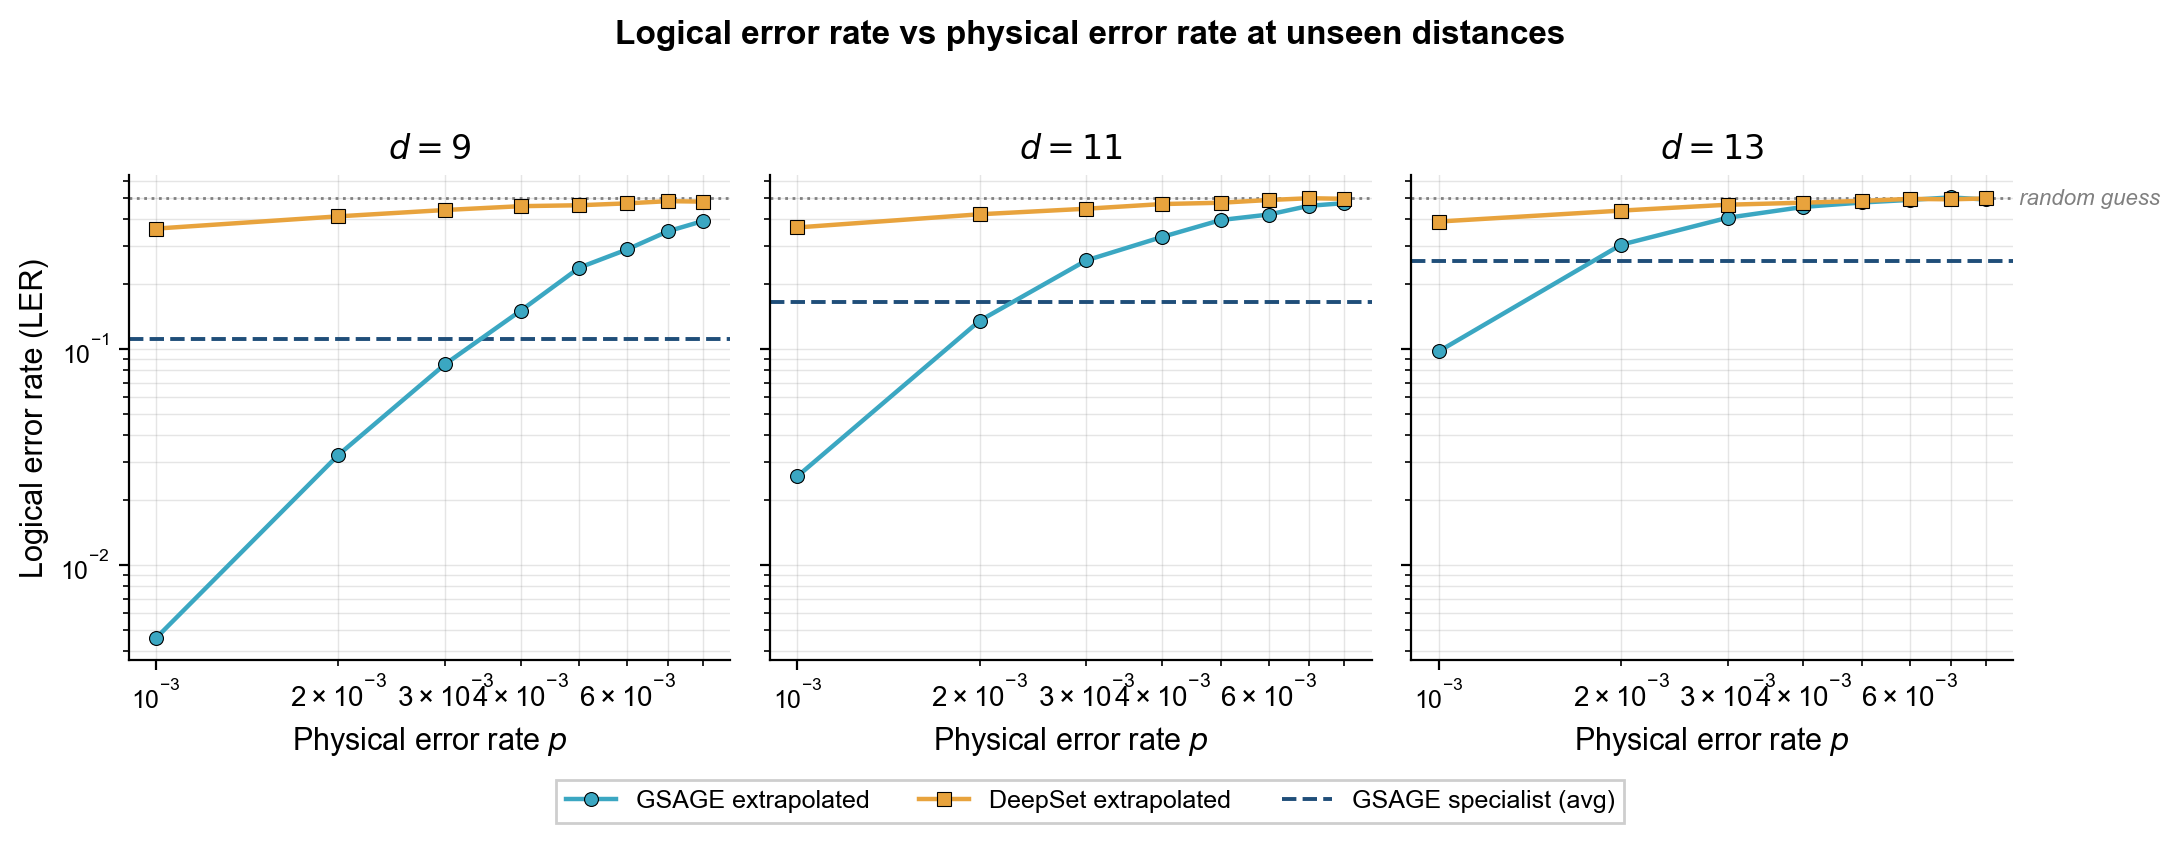

In [8]:
# === LER version: per-distance LER vs physical error rate (log-log) ===
# Specialists were trained on a mix of p in {0.001, 0.003, 0.005, 0.007} and only
# have a single averaged val_accuracy per d (no per-p test sweep), so they are
# shown as a horizontal dashed reference per panel.
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_here = Path(".").resolve()
_workspace_candidates = [
    _here, _here.parent, _here.parent.parent, _here.parent.parent.parent,
    Path("/Users/billxu/quantum-error-correction"),
]
REPO_ROOT = next(
    (p for p in _workspace_candidates
     if (p / "code" / "gSAGE" / "distances" / "results" / "revised_training").exists()),
    _here,
)

SPEC_DIR    = REPO_ROOT / "code" / "gSAGE" / "distances"   / "results" / "revised_training"
GSAGE_EXT   = REPO_ROOT / "code" / "gSAGE" / "extrapolation" / "results" / "revised_training" / "extrapolation_results.csv"
DEEPSET_EXT = REPO_ROOT / "code" / "deepsets" / "extrapolation" / "results" / "revised_training" / "extrapolation_results.csv"

DISTANCES = [9, 11, 13]

# --- Specialist: single averaged LER per d (no per-p sweep available) ---
specialist_ler = {}
for d in DISTANCES:
    with open(SPEC_DIR / f"d{d}_training.json") as f:
        acc = json.load(f)["final_metrics"]["val_accuracy"]
    specialist_ler[d] = 1.0 - acc

# --- GSAGE extrapolated: per-p LER for b3_balanced ---
df_g = pd.read_csv(GSAGE_EXT)
gsage_b3 = df_g[df_g["split_name"] == "b3_balanced"].copy()

# --- DeepSet: per-p LER for equal_333333 ---
df_d = pd.read_csv(DEEPSET_EXT)
deepset_eq = df_d[df_d["split_name"] == "equal_333333"].copy()

print("Per-p LER values (LER = 1 - accuracy):")
for d in DISTANCES:
    g_sub = gsage_b3[gsage_b3["distance"] == d].sort_values("p_value")
    d_sub = deepset_eq[deepset_eq["distance"] == d].sort_values("p_value")
    print(f"\n  d = {d}  (specialist avg LER = {specialist_ler[d]:.4f})")
    print(f"    {'p':>7} | {'GSAGE-ext':>10} | {'DeepSet':>10}")
    for p in sorted(g_sub["p_value"].unique()):
        g = g_sub.loc[g_sub["p_value"] == p, "ler"].iloc[0]
        d_ = d_sub.loc[d_sub["p_value"] == p, "ler"].iloc[0] if (d_sub["p_value"] == p).any() else np.nan
        print(f"    {p:>7.3f} | {g:>10.4f} | {d_:>10.4f}")

# --- Plot: 1 row x 3 cols, log-log ---
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})

fig, axes = plt.subplots(1, 3, figsize=(11, 4.0), dpi=200, sharey=True)

C_SPEC = "#1f4e79"
C_EXT  = "#3BA7C2"
C_DS   = "#E8A33D"

for ax, d in zip(axes, DISTANCES):
    g_sub = gsage_b3[gsage_b3["distance"] == d].sort_values("p_value")
    d_sub = deepset_eq[deepset_eq["distance"] == d].sort_values("p_value")

    # Extrapolated GSAGE
    ax.plot(g_sub["p_value"], g_sub["ler"],
            "-o", color=C_EXT, markersize=5, linewidth=1.6,
            markeredgecolor="black", markeredgewidth=0.4,
            label="GSAGE extrapolated", zorder=3)
    # DeepSet
    ax.plot(d_sub["p_value"], d_sub["ler"],
            "-s", color=C_DS, markersize=5, linewidth=1.6,
            markeredgecolor="black", markeredgewidth=0.4,
            label="DeepSet extrapolated", zorder=3)
    # Specialist (single number, dashed reference)
    ax.axhline(specialist_ler[d], color=C_SPEC, linestyle="--", linewidth=1.4,
               label="GSAGE specialist (avg)", zorder=2)

    # Random guess (LER = 0.5)
    ax.axhline(0.5, color="gray", linestyle=":", linewidth=1.0, zorder=1)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Physical error rate $p$", fontsize=11)
    ax.set_title(fr"$d{{=}}{d}$", fontsize=12, fontweight="bold")
    ax.grid(True, which="both", alpha=0.25, linestyle="-", linewidth=0.5, color="#999999")
    ax.set_axisbelow(True)
    ax.tick_params(axis="both", labelsize=9)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

axes[0].set_ylabel("Logical error rate (LER)", fontsize=11)

# Random-guess label on rightmost panel
axes[-1].text(axes[-1].get_xlim()[1], 0.5, " random guess",
              color="gray", fontsize=8, style="italic", va="center", ha="left",
              clip_on=False)

# Single legend, bottom of the figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=9,
           frameon=True, fancybox=False, framealpha=0.95, edgecolor="#cccccc",
           bbox_to_anchor=(0.5, -0.02))

fig.suptitle("Logical error rate vs physical error rate at unseen distances",
             fontsize=12, fontweight="bold", y=1.0)

plt.tight_layout(rect=[0, 0.04, 1, 0.97])

# --- Save ---
PLOTS_DIR_LOCAL = REPO_ROOT / "code" / "gSAGE" / "extrapolation" / "plots" / "revised_training"
PLOTS_DIR_LOCAL.mkdir(parents=True, exist_ok=True)
png_path = PLOTS_DIR_LOCAL / "extrapolation_gap_ler.png"
pdf_path = PLOTS_DIR_LOCAL / "extrapolation_gap_ler.pdf"
fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
print(f"\nSaved: {png_path}")
print(f"Saved: {pdf_path}")
plt.show()
plt.close(fig)
